# Donut Fine-Tuning pada CORD v2
**LaporKeuangan · Coding Camp 2026 · DBS Foundation**

Fine-tuning `donut-base-finetuned-cord-v2` dengan dataset CORD v2
untuk meningkatkan akurasi parsing struk Indonesia.

### Kenapa fine-tuning dari `donut-base-finetuned-cord-v2`?
Model ini sudah punya knowledge struk Indonesia dari CORD v1.
Fine-tuning dengan CORD v2 (versi lebih bersih dengan label yang diperbaiki)
akan memperkuat kemampuan model tanpa training dari nol.

### Urutan cell:
1. Install & Setup
2. Load CORD v2
3. Eksplorasi dataset
4. Load model Donut
5. Preprocessing
6. Training
7. Simpan ke Drive
8. Test hasil fine-tuning


## Cell 1 — Install

In [ ]:
!pip install donut-python transformers datasets sentencepiece -q
!pip install Pillow numpy torch torchvision -q

print("Instalasi selesai.")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 6.3 MB/s eta 0:00:00
Instalasi selesai.


## Cell 2 — Import & Setup

In [ ]:
import os, re, json, time, random
import numpy as np
from pathlib import Path
from PIL import Image as PILImage
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    DonutProcessor,
    VisionEncoderDecoderModel,
    VisionEncoderDecoderConfig,
    get_linear_schedule_with_warmup,
)
from datasets import load_dataset

# Cek GPU
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA ok  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\nDevice   : {DEVICE}")

if DEVICE == "cpu":
    print("PERINGATAN: GPU tidak aktif!")
    print("Aktifkan: Runtime → Change runtime type → T4 GPU")

PyTorch  : 2.10.0+cu128
CUDA ok  : True
GPU      : Tesla T4
VRAM     : 15.6 GB

Device   : cuda


## Cell 3 — Load CORD v2

In [ ]:
print("Loading CORD v2 dari HuggingFace...")
print("(Butuh koneksi internet, ukuran ~500MB)")

dataset = load_dataset("naver-clova-ix/cord-v2")

print(f"\nDataset berhasil diload:")
print(f"  Train : {len(dataset['train'])} sampel")
print(f"  Val   : {len(dataset['validation'])} sampel")
print(f"  Test  : {len(dataset['test'])} sampel")

# Lihat contoh satu sampel
sample = dataset['train'][0]
print(f"\nKunci di setiap sampel: {list(sample.keys())}")
print(f"Ukuran gambar sampel 0 : {sample['image'].size}")

Loading CORD v2 dari HuggingFace...
(Butuh koneksi internet, ukuran ~500MB)


README.md:   0%|          | 0.00/27.0 [00:00<?, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-b4aaeceff1d90e(…):   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00001-of-00004-7dbbe248962764(…):   0%|          | 0.00/441M [00:00<?, ?B/s]

...

data/test-00000-of-00001-9c204eb3f4e1179(…):   0%|          | 0.00/234M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/800 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]


Dataset berhasil diload:
  Train : 800 sampel
  Val   : 100 sampel
  Test  : 100 sampel

Kunci di setiap sampel: ['image', 'ground_truth']
Ukuran gambar sampel 0 : (864, 1296)


## Cell 4 — Eksplorasi Dataset

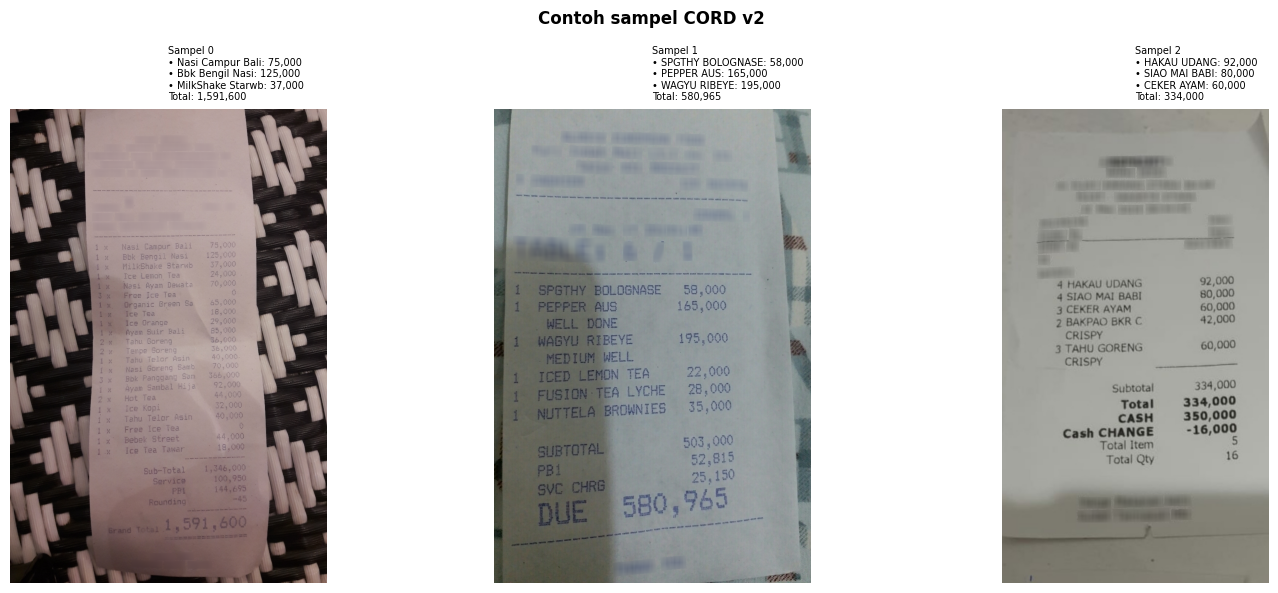

Tersimpan: cord_v2_samples.png

=== Statistik CORD v2 ===
Rata-rata item per struk : 2.6
Max item per struk       : 22
Min item per struk       : 1


In [ ]:
import matplotlib.pyplot as plt

# Tampilkan 3 sampel pertama
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle("Contoh sampel CORD v2", fontsize=12, fontweight="bold")

for i, ax in enumerate(axes):
    sample = dataset['train'][i]
    img    = sample['image']
    gt     = json.loads(sample['ground_truth'])

    ax.imshow(img)
    ax.axis("off")

    # Tampilkan info
    menu = gt.get("gt_parse", {}).get("menu", [])
    if isinstance(menu, dict): menu = [menu]
    total = gt.get("gt_parse", {}).get("total", {})

    items_str = "\n".join([
        f"• {m.get('nm','?')}: {m.get('price','?')}"
        for m in (menu if isinstance(menu, list) else [])[:3]
    ])
    total_str = total.get("total_price", "?") if isinstance(total, dict) else "?"
    ax.set_title(
        f"Sampel {i}\n{items_str}\nTotal: {total_str}",
        fontsize=7, ha="left"
    )

plt.tight_layout()
plt.savefig("cord_v2_samples.png", dpi=100, bbox_inches="tight")
plt.show()
print("Tersimpan: cord_v2_samples.png")

# Statistik dataset
print("\n=== Statistik CORD v2 ===")
n_menu_items = []
for s in dataset['train']:
    gt   = json.loads(s['ground_truth'])
    menu = gt.get("gt_parse", {}).get("menu", [])
    if isinstance(menu, dict): menu = [menu]
    if isinstance(menu, list): n_menu_items.append(len(menu))

print(f"Rata-rata item per struk : {np.mean(n_menu_items):.1f}")
print(f"Max item per struk       : {max(n_menu_items)}")
print(f"Min item per struk       : {min(n_menu_items)}")

## Cell 5 — Load Model Donut

In [ ]:
from transformers import DonutProcessor, VisionEncoderDecoderModel

MODEL_NAME = "naver-clova-ix/donut-base"

print("Loading processor...")
processor = DonutProcessor.from_pretrained(MODEL_NAME, use_fast=False)

print("Loading model...")
model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)
model = model.to(DEVICE)

# ── FIX: Sinkronisasi vocab tokenizer dengan embedding model ──────────

# 1. Tambahkan special tokens CORD v2
new_tokens = ["<s_cord-v2>", "</s_cord-v2>"]

# Cara yang kompatibel dengan slow tokenizer
existing = processor.tokenizer.all_special_tokens
to_add   = [t for t in new_tokens if t not in existing]

if to_add:
    processor.tokenizer.add_special_tokens(
        {"additional_special_tokens": to_add}
    )
    print(f"Token ditambahkan: {to_add}")
else:
    print("Token sudah ada di vocab.")

# 2. Resize embedding matrix agar sinkron dengan vocab baru
model.decoder.resize_token_embeddings(len(processor.tokenizer))

# 3. Update config
model.config.decoder.vocab_size = len(processor.tokenizer)
model.config.vocab_size          = len(processor.tokenizer)

# 4. Set decoder config untuk generation
model.config.decoder_start_token_id = processor.tokenizer.convert_tokens_to_ids(
    "<s_cord-v2>"
)
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.eos_token_id = processor.tokenizer.eos_token_id

# ── Verifikasi ────────────────────────────────────────────────────────
vocab_size = len(processor.tokenizer)
token_id   = processor.tokenizer.convert_tokens_to_ids("<s_cord-v2>")

# Cari embed_tokens di MBartDecoderWrapper
embed_size = model.decoder.model.decoder.embed_tokens.weight.shape[0]

print(f"\nVokab tokenizer     : {vocab_size}")
print(f"Embedding size      : {embed_size}")
print(f"Token ID <s_cord-v2>: {token_id}")
print(f"Status: {'OK - sinkron' if vocab_size == embed_size else 'MISMATCH!'}")

# Cek lm_head juga
lm_head_size = model.decoder.lm_head.weight.shape[0]
print(f"LM Head size        : {lm_head_size}")
print(f"LM Head sinkron     : {'OK' if lm_head_size == vocab_size else 'MISMATCH!'}")

Loading processor...
Loading model...


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Token ditambahkan: ['<s_cord-v2>', '</s_cord-v2>']

Vokab tokenizer     : 57527
Embedding size      : 57527
Token ID <s_cord-v2>: 57525
Status: OK - sinkron
LM Head size        : 57527
LM Head sinkron     : OK


## Cell 6 — Dataset Class & Preprocessing

In [ ]:
class CORDv2Dataset(Dataset):
    def __init__(self, hf_split, processor, max_length=256, split="train"):
        self.data       = hf_split
        self.processor  = processor
        self.max_length = max_length
        self.split      = split
        self.task_start_token = "<s_cord-v2>"
        self.eos_token        = processor.tokenizer.eos_token
        print(f"  Dataset [{split}]: {len(hf_split)} sampel, max_length={max_length}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]

        img = sample["image"]
        if not isinstance(img, PILImage.Image):
            img = PILImage.fromarray(np.array(img))
        img = img.convert("RGB")

        pixel_values = self.processor(
            img, return_tensors="pt"
        ).pixel_values.squeeze(0)

        gt      = json.loads(sample["ground_truth"])
        gt_json = gt.get("gt_parse", {})
        gt_str  = json.dumps(gt_json, ensure_ascii=False)

        target_sequence = (
            f"{self.task_start_token}{gt_str}"
            f"{self.eos_token}"
        )

        input_ids = self.processor.tokenizer(
            target_sequence,
            add_special_tokens = False,
            max_length         = self.max_length,
            padding            = "max_length",
            truncation         = True,
            return_tensors     = "pt",
        ).input_ids.squeeze(0)

        labels = input_ids.clone()
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {
            "pixel_values": pixel_values,
            "labels"      : labels,
        }


# Build dataset dengan max_length=256 (hemat VRAM)
print("Membangun dataset...")
train_dataset = CORDv2Dataset(dataset["train"],      processor, max_length=256, split="train")
val_dataset   = CORDv2Dataset(dataset["validation"], processor, max_length=256, split="val")

BATCH_SIZE   = 2
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\nTrain batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

# Test satu batch
for batch in train_loader:
    print(f"\nTest batch:")
    print(f"  pixel_values : {batch['pixel_values'].shape}")
    print(f"  labels       : {batch['labels'].shape}")
    break
print("Dataset siap.")

Membangun dataset...
  Dataset [train]: 800 sampel, max_length=256
  Dataset [val]: 100 sampel, max_length=256

Train batches : 400
Val batches   : 50

Test batch:
  pixel_values : torch.Size([2, 3, 2560, 1920])
  labels       : torch.Size([2, 256])
Dataset siap.


## Cell 7 — Training

In [ ]:
from torch.amp import autocast, GradScaler # Corrected import
import matplotlib.pyplot as plt


# ── Freeze encoder — hanya train decoder ──────────────────────────────
for param in model.encoder.parameters():
    param.requires_grad = False

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")
print(f"Frozen params    : {total_params-trainable_params:,} (encoder)")

# ── Gradient checkpointing untuk hemat VRAM ───────────────────────────
model.gradient_checkpointing_enable()
print("Gradient checkpointing: aktif")

# ── Bersihkan cache GPU sebelum training ──────────────────────────────
torch.cuda.empty_cache()
print(f"VRAM tersedia: {torch.cuda.memory_reserved(0)/1e9:.1f} GB reserved")

# ── Hyperparameter ────────────────────────────────────────────────────
EPOCHS       = 5
LR           = 5e-5
WARMUP_RATIO = 0.1
SAVE_DIR     = "donut_finetuned_cord_v2"
Path(SAVE_DIR).mkdir(exist_ok=True)

# ── Optimizer & Scheduler ─────────────────────────────────────────────
optimizer    = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=0.01
)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps,
)
scaler = torch.amp.GradScaler('cuda')  # untuk mixed precision

print("\n" + "=" * 60)
print("FINE-TUNING Donut — Decoder Only + Mixed Precision")
print("=" * 60)
print(f"  Epochs       : {EPOCHS}")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  LR           : {LR}")
print(f"  Max length   : 256 (dari 768)")
print(f"  Total steps  : {total_steps}")
print(f"  Device       : {DEVICE}")
print("-" * 60)

best_val_loss = float("inf")
history       = []

for epoch in range(EPOCHS):
    t_start = time.time()

    # ── TRAINING ──────────────────────────────────────────────────────
    model.train()
    tr_loss, tr_n, tr_skip = 0.0, 0, 0

    pbar = tqdm(train_loader,
                desc=f"Epoch {epoch+1}/{EPOCHS} [train]",
                leave=False)
    for batch in pbar:
        pixel_values = batch["pixel_values"].to(DEVICE)
        labels       = batch["labels"].to(DEVICE)

        optimizer.zero_grad()
        try:
            # Mixed precision forward pass
            with autocast('cuda'):
                outputs = model(
                    pixel_values = pixel_values,
                    labels       = labels,
                )
                loss = outputs.loss

            if loss is None or torch.isnan(loss) or torch.isinf(loss):
                tr_skip += 1
                continue

            # Scaled backward pass
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                filter(lambda p: p.requires_grad, model.parameters()), 1.0
            )
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            tr_loss += loss.item()
            tr_n    += 1
            pbar.set_postfix(loss=f"{tr_loss/max(tr_n,1):.4f}")

        except RuntimeError as e:
            if "out of memory" in str(e):
                torch.cuda.empty_cache()
            tr_skip += 1
            optimizer.zero_grad()
            continue

    # ── VALIDATION ────────────────────────────────────────────────────
    model.eval()
    vl_loss, vl_n = 0.0, 0

    with torch.no_grad():
        for batch in tqdm(val_loader,
                          desc=f"Epoch {epoch+1}/{EPOCHS} [val]",
                          leave=False):
            pixel_values = batch["pixel_values"].to(DEVICE)
            labels       = batch["labels"].to(DEVICE)
            try:
                with autocast('cuda'):
                    outputs = model(
                        pixel_values = pixel_values,
                        labels       = labels,
                    )
                if outputs.loss is not None:
                    vl_loss += outputs.loss.item()
                    vl_n    += 1
            except RuntimeError:
                torch.cuda.empty_cache()
                continue

    avg_tr  = tr_loss / max(tr_n, 1)
    avg_vl  = vl_loss / max(vl_n, 1)
    elapsed = time.time() - t_start
    cur_lr  = scheduler.get_last_lr()[0] if tr_n > 0 else 0

    log = {
        "epoch"     : epoch + 1,
        "train_loss": round(avg_tr, 4),
        "val_loss"  : round(avg_vl, 4),
        "lr"        : round(cur_lr, 8),
        "skip"      : tr_skip,
        "time_s"    : round(elapsed, 1),
    }
    history.append(log)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"train_loss={avg_tr:.4f} | val_loss={avg_vl:.4f} | "
          f"lr={cur_lr:.2e} | skip={tr_skip} | {elapsed:.0f}s")

    if avg_vl < best_val_loss and vl_n > 0 and tr_n > 0:
        best_val_loss = avg_vl
        model.save_pretrained(SAVE_DIR)
        processor.save_pretrained(SAVE_DIR)
        print(f"  Saved best model (val_loss={avg_vl:.4f})")

print("\n" + "=" * 60)
print("FINE-TUNING SELESAI!")
print(f"  Best val loss : {best_val_loss:.4f}")
print(f"  Sukses train  : {sum(h['epoch'] for h in history if h['train_loss'] > 0)} epoch")
print("=" * 60)

Total params     : 201,854,072
Trainable params : 127,673,344 (63.3%)
Frozen params    : 74,180,728 (encoder)
Gradient checkpointing: aktif
VRAM tersedia: 0.9 GB reserved

FINE-TUNING Donut — Decoder Only + Mixed Precision
  Epochs       : 5
  Batch size   : 2
  LR           : 5e-05
  Max length   : 256 (dari 768)
  Total steps  : 2000
  Device       : cuda
------------------------------------------------------------


Epoch 1/5 [train]:   0%|          | 0/400 [00:00<?, ?it/s]`use_cache=True` is incompatible with gradient checkpointing`. Setting `use_cache=False`...
/tmp/ipykernel_5957/420064959.py:94: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch 1/5 | train_loss=1.1055 | val_loss=0.2514 | lr=4.44e-05 | skip=0 | 1094s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Saved best model (val_loss=0.2514)


...

  Saved best model (val_loss=0.1442)


Epoch 4/5 | train_loss=0.1096 | val_loss=0.1415 | lr=1.11e-05 | skip=0 | 1078s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Saved best model (val_loss=0.1415)


Epoch 5/5 | train_loss=0.0844 | val_loss=0.1427 | lr=0.00e+00 | skip=0 | 1085s

FINE-TUNING SELESAI!
  Best val loss : 0.1415
  Sukses train  : 15 epoch


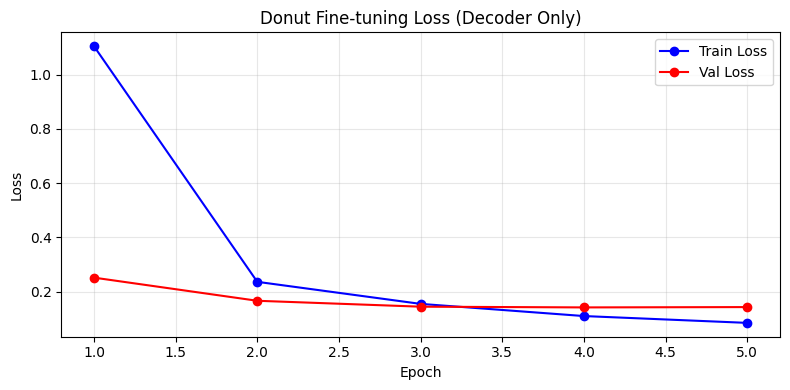

In [ ]:

# Plot
if history and any(h['train_loss'] > 0 for h in history):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot([h["epoch"] for h in history],
            [h["train_loss"] for h in history], "b-o", label="Train Loss")
    ax.plot([h["epoch"] for h in history],
            [h["val_loss"] for h in history],   "r-o", label="Val Loss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title("Donut Fine-tuning Loss (Decoder Only)")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("donut_training_loss.png", dpi=100)
    plt.show()

## Cell 8 — Simpan ke Google Drive

In [ ]:
SAVE_TO_DRIVE = True  # ganti False jika tidak mau simpan ke Drive

if SAVE_TO_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive')

        import shutil
        drive_path = '/content/drive/MyDrive/LaporKeuangan/donut_finetuned_cord_v2'

        print(f"Menyalin model ke Drive: {drive_path}")
        shutil.copytree(SAVE_DIR, drive_path, dirs_exist_ok=True)
        print(f"Berhasil!")
        print(f"\nCara load di notebook inference:")
        print(f"  processor = DonutProcessor.from_pretrained('{drive_path}')")
        print(f"  model     = VisionEncoderDecoderModel.from_pretrained('{drive_path}')")

    except Exception as e:
        print(f"Gagal simpan ke Drive: {e}")
        print(f"Model tersimpan lokal di: {SAVE_DIR}/")
        print("Download folder ini sebelum runtime direset.")
        print()
        print("Cara download di Colab:")
        print("  import shutil")
        print(f"  shutil.make_archive('{SAVE_DIR}', 'zip', '{SAVE_DIR}')")
        print(f"  files.download('{SAVE_DIR}.zip')")
else:
    print(f"Model tersimpan lokal: {SAVE_DIR}/")

Mounted at /content/drive
Menyalin model ke Drive: /content/drive/MyDrive/LaporKeuangan/donut_finetuned_cord_v2
Berhasil!

Cara load di notebook inference:
  processor = DonutProcessor.from_pretrained('/content/drive/MyDrive/LaporKeuangan/donut_finetuned_cord_v2')
  model     = VisionEncoderDecoderModel.from_pretrained('/content/drive/MyDrive/LaporKeuangan/donut_finetuned_cord_v2')


## Cell 9 — Test Model Fine-tuned

In [ ]:
# Load model yang sudah fine-tuned
from google.colab import drive
from transformers import DonutProcessor, VisionEncoderDecoderModel
import torch
drive.mount('/content/drive')

# Path model di Drive
SAVE_DIR = "/content/drive/MyDrive/LaporKeuangan/donut_finetuned_cord_v2"
print("Loading model fine-tuned...")
model_ft    = VisionEncoderDecoderModel.from_pretrained(SAVE_DIR)
processor_ft= DonutProcessor.from_pretrained(SAVE_DIR)
model_ft    = model_ft.to(DEVICE)
model_ft.eval()
print("Model fine-tuned siap.")

def predict_ft(image_input, max_new_tokens=512):
    """Inference dengan model fine-tuned."""
    if isinstance(image_input, (str, Path)):
        img_pil = PILImage.open(str(image_input)).convert("RGB")
    elif isinstance(image_input, np.ndarray):
        img_pil = PILImage.fromarray(image_input).convert("RGB")
    else:
        img_pil = image_input.convert("RGB")

    # Resize jika terlalu besar
    W, H = img_pil.size
    if max(W, H) > 1920:
        scale   = 1920 / max(W, H)
        img_pil = img_pil.resize((int(W*scale), int(H*scale)))

    task_prompt       = "<s_cord-v2>"
    decoder_input_ids = processor_ft.tokenizer(
        task_prompt,
        add_special_tokens = False,
        return_tensors     = "pt"
    ).input_ids.to(DEVICE)

    pixel_values = processor_ft(
        img_pil, return_tensors="pt"
    ).pixel_values.to(DEVICE)

    with torch.no_grad():
        outputs = model_ft.generate(
            pixel_values,
            decoder_input_ids       = decoder_input_ids,
            max_new_tokens          = max_new_tokens,
            early_stopping          = True,
            pad_token_id            = processor_ft.tokenizer.pad_token_id,
            eos_token_id            = processor_ft.tokenizer.eos_token_id,
            use_cache               = True,
            num_beams               = 1,
            bad_words_ids           = [[processor_ft.tokenizer.unk_token_id]],
            return_dict_in_generate = True,
        )

    sequence = processor_ft.batch_decode(outputs.sequences)[0]
    sequence = sequence.replace(processor_ft.tokenizer.eos_token, "")
    sequence = sequence.replace(processor_ft.tokenizer.pad_token, "")
    sequence = re.sub(r"<.*?>", "", sequence, count=1).strip()

    return processor_ft.token2json(sequence)


# ── Test dengan gambar CORD v2 validation ─────────────────────────────
print("\nTest pada CORD v2 validation set...")
sample      = dataset["validation"][0]
img_pil     = sample["image"].convert("RGB")
gt          = json.loads(sample["ground_truth"])
gt_parse    = gt.get("gt_parse", {})

print("Ground Truth:")
print(json.dumps(gt_parse, indent=2, ensure_ascii=False)[:400])

print("\nPrediksi Fine-tuned:")
pred = predict_ft(img_pil)
print(json.dumps(pred, indent=2, ensure_ascii=False)[:400])

# ── Test dengan upload foto struk ─────────────────────────────────────
print("\n" + "="*50)
print("Upload foto struk untuk test model fine-tuned:")
from google.colab import files
import io

uploaded = files.upload()
if uploaded:
    fname   = list(uploaded.keys())[0]
    fbytes  = uploaded[fname]
    img_pil = PILImage.open(io.BytesIO(fbytes)).convert("RGB")

    print(f"\nFile: {fname}")
    print("Menjalankan Donut fine-tuned...")

    t0   = time.time()
    pred = predict_ft(img_pil)
    print(f"Selesai dalam {time.time()-t0:.1f}s")

    print("\nOutput JSON:")
    print(json.dumps(pred, indent=2, ensure_ascii=False))

    # Parse item dan total
    menu  = pred.get("menu", [])
    if isinstance(menu, dict): menu = [menu]
    total = pred.get("total", {})

    print("\nItem terdeteksi:")
    for item in (menu if isinstance(menu, list) else []):
        if isinstance(item, dict):
            nm    = item.get("nm",    "-")
            price = item.get("price", "0")
            cnt   = item.get("cnt",   "")
            print(f"  {cnt} {nm}: {price}".strip())

    total_price = (total.get("total_price", "0")
                   if isinstance(total, dict) else "0")
    print(f"\nTotal: {total_price}")

Loading model fine-tuned...


Loading weights:   0%|          | 0/483 [00:00<?, ?it/s]

Model fine-tuned siap.

Test pada CORD v2 validation set...
Ground Truth:
{
  "menu": [
    {
      "nm": "REAL GANACHE",
      "cnt": "1",
      "price": "16,500"
    },
    {
      "nm": "EGG TART",
      "cnt": "1",
      "price": "13,000"
    },
    {
      "nm": "PIZZA TOAST",
      "cnt": "1",
      "price": "16,000"
    }
  ],
  "total": {
    "total_price": "45,500",
    "cashprice": "50,000",
    "changeprice": "4,500"
  }
}

Prediksi Fine-tuned:
{
  "text_sequence": " {\"menu\": [{\"nm\": \"REA GAMACHE\", \"cnt\": \"4\", \"price\": \"16,500\"}, {\"nm\": \"EGG TART\", \"cnt\": \"4\", \"price\": \"13,000\"}, {\"nm\": \"PIZZA TOAST\", \"cnt\": \"4\", \"price\": \"16,000\"}], \"total\": {\"total_price\": \"45,000\", \"cashprice\": \"50,000\", \"changeprice\": \"4,500\"}}"
}

Upload foto struk untuk test model fine-tuned:


Saving struk makanan.jpg to struk makanan.jpg

File: struk makanan.jpg
Menjalankan Donut fine-tuned...
Selesai dalam 4.4s

Output JSON:
{
  "text_sequence": " {\"menu\": [{\"nm\": \"2022-04–14\", \"cnt\": \"14\", \"price\": \"Afi sheila\", \"cnt\": \"2\", \"price\": \"Rp 12.000\"}, {\"nm\": \"Nasi Ayam Geprek\", \"cnt\": \"2\", \"price\": \"Rp 15.000\"}, {\"nm\": \"X 12.000\", \"cnt\": \"2\", \"price\": \"Rp 15.000\"}, {\"nm\": \"Nasi Ayam Kremes\", \"cnt\": \"2\", \"price\": \"Rp 15.000\"}, {\"nm\": \"X 15.000\", \"cnt\": \"2\", \"price\": \"Rp 20.000\"}, {\"nm\": \"Nasi Goreng Spesial\", \"cnt\": \"2\", \"price\": \"47.000\"}, {\"nm\": \"X 20.000\", \"cnt\": \"2\", \"price\": \"47.000\"}], \"sub_total\": {\"subtotal_price\": \"47.000\", \"tax_price\": \"47.000\"}, \"total\": \"total_etc\": \"cashprice\": \"changeprice\"}}"
}

Item terdeteksi:

Total: 0
